#Telecom x parte 2

# Parte 1

In [2]:
# Parte 1 🛠️ Preparação dos Dados
# 1.1 Extração do Arquivo Tratado

import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Curso Alura/dados_normalizados.csv')

In [11]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

In [3]:
#1.2 # Visualizando as primeiras linhas para confirmar o carregamento
display(df.head())

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,Yes,No,Yes,Yes,No,One year,1,Mailed check,65.6,590.4
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,539.1
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,295.6
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1274.0
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,251.7


In [4]:
# 1.3 Remoção de Colunas Irrelevantes
# O customerID não tem poder preditivo e pode confundir o modelo
df = df.drop(columns=['customerID'])

In [5]:
# 1.4 Encoding
# Transformando as variáveis categóricas em formato numérico (One-Hot Encoding)
# Utilizamos drop_first=True para evitar multicolinearidade (a "armadilha das variáveis dummy")
df_encoded = pd.get_dummies(df, drop_first=True)

In [6]:
# 1.5 Verificação da Proporção de Evasão
print("\n--- Proporção de Evasão (Churn) ---")
contagem = df['Churn'].value_counts()
proporcao = df['Churn'].value_counts(normalize=True) * 100
resumo_churn = pd.DataFrame({'Quantidade': contagem, 'Proporção (%)': proporcao.round(2)})
display(resumo_churn)


--- Proporção de Evasão (Churn) ---


,Quantidade,Proporção (%)
Churn,,
0,5174,73.46
1,1869,26.54


In [7]:
# Garantindo que os dados booleanos gerados pelo get_dummies virem inteiros (0 e 1)
df_encoded = df_encoded.astype(float)

In [8]:
print(f"\nTotal de colunas após o encoding: {df_encoded.shape[1]}")
display(df_encoded.head())


Total de colunas após o encoding: 31


,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Monthly,Total,gender_Male,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,0.0,1.0,1.0,9.0,1.0,1.0,65.6,590.4,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,9.0,1.0,0.0,59.9,539.1,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,0.0,4.0,1.0,1.0,73.9,295.6,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.0,1.0,1.0,0.0,13.0,1.0,1.0,98.0,1274.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,1.0,1.0,1.0,0.0,3.0,1.0,1.0,83.9,251.7,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [14]:
# Definindo quem são as features (X) e quem é o nosso alvo (y)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

In [15]:
# 2.3 Separação de Dados (Fazemos isso antes do SMOTE/Scaler!)
# Estratificamos pelo 'y' para garantir que a proporção de Churn seja mantida no treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [16]:
# 1.6 Balanceamento

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [17]:
# 1.7 Normalização

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)

In [19]:
# O teste é transformado usando as regras do treino, sem 'fit' para evitar vazamento
X_test_scaled = scaler.transform(X_test)

print(f"✨ Tamanho do treino ANTES do SMOTE: {X_train.shape[0]}")
print(f"✨ Tamanho do treino APÓS o SMOTE: {X_train_resampled.shape[0]}")

✨ Tamanho do treino ANTES do SMOTE: 4930
✨ Tamanho do treino APÓS o SMOTE: 7244


# Célula 2: Análise de Correlação e Direcionada

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

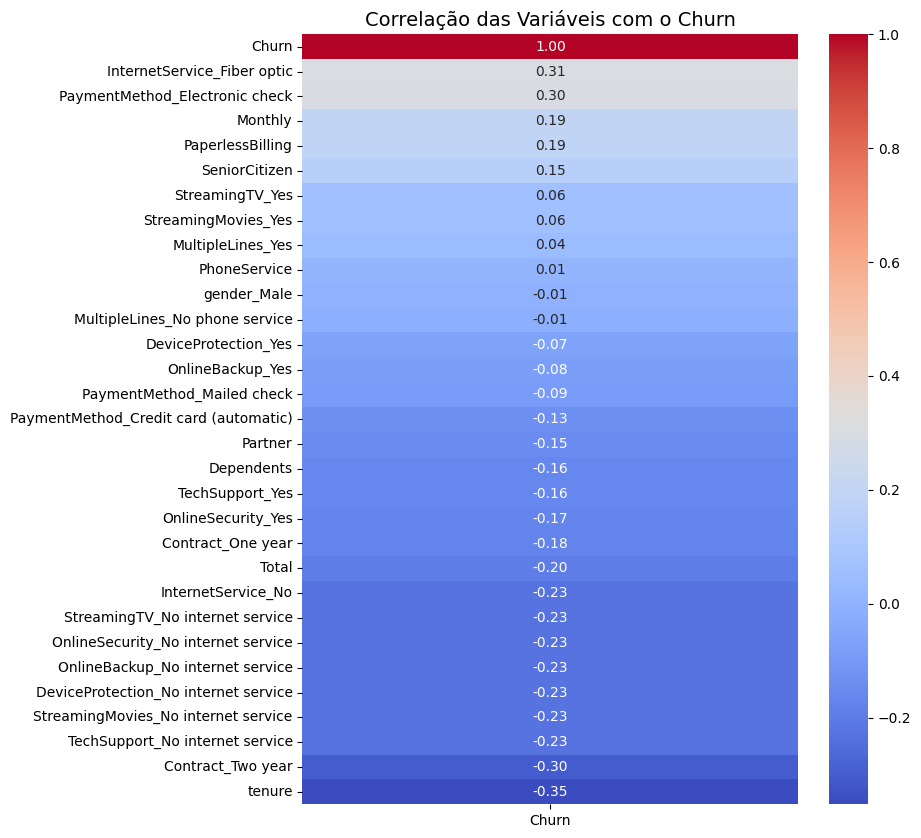

/tmp/ipykernel_2232/3181450867.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[0], palette='magma')
/tmp/ipykernel_2232/3181450867.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Permaneceu', 'Evadiu'])
/tmp/ipykernel_2232/3181450867.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Total', data=df, ax=axes[1], palette='magma')
/tmp/ipykernel_2232/3181450867.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels

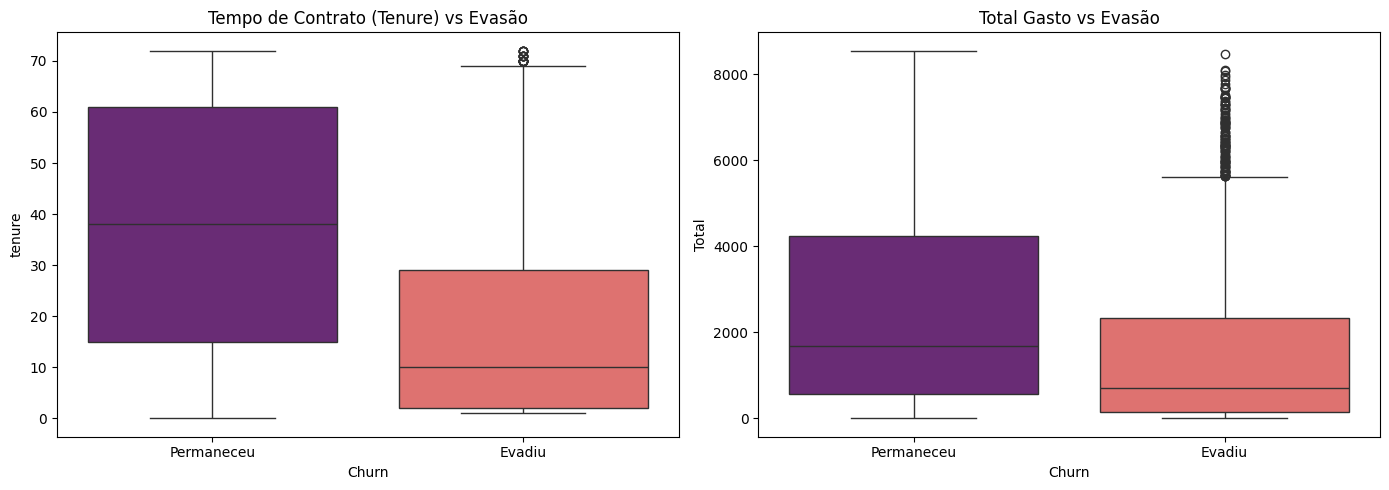

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2.1 Análise de Correlação (Focando no Churn)
plt.figure(figsize=(8, 10))
correlacao = df_encoded.corr()
# Pegamos apenas a correlação com a variável alvo e ordenamos
sns.heatmap(correlacao[['Churn']].sort_values(by='Churn', ascending=False), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlação das Variáveis com o Churn', fontsize=14)
plt.show()

# 2.2 Análises Direcionadas
# Como o Tenure (Tempo de Contrato) e o Total Gasto influenciam?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Como a variável original se perdeu no encoding (para o gráfico), vamos usar o df original
sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[0], palette='magma')
axes[0].set_title('Tempo de Contrato (Tenure) vs Evasão')
axes[0].set_xticklabels(['Permaneceu', 'Evadiu'])

sns.boxplot(x='Churn', y='Total', data=df, ax=axes[1], palette='magma')
axes[1].set_title('Total Gasto vs Evasão')
axes[1].set_xticklabels(['Permaneceu', 'Evadiu'])

plt.tight_layout()
plt.show()

 Resultados: Regressão Logística 
              precision    recall  f1-score   support

         0.0       0.91      0.73      0.81      1552
         1.0       0.51      0.80      0.62       561

    accuracy                           0.75      2113
   macro avg       0.71      0.76      0.72      2113
weighted avg       0.80      0.75      0.76      2113


 Resultados: Random Forest 
              precision    recall  f1-score   support

         0.0       0.83      0.88      0.85      1552
         1.0       0.60      0.49      0.54       561

    accuracy                           0.78      2113
   macro avg       0.71      0.69      0.70      2113
weighted avg       0.77      0.78      0.77      2113



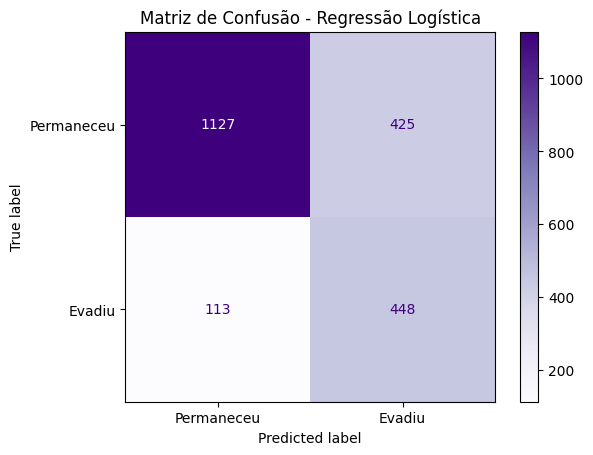

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- Modelo 1: Regressão Logística (Exige dados normalizados) ---
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train_resampled)
y_pred_lr = lr_model.predict(X_test_scaled)

# --- Modelo 2: Random Forest (Não exige dados normalizados) ---
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)
y_pred_rf = rf_model.predict(X_test) # Usamos X_test sem scaler!

# 2.5 Avaliação dos Modelos
print(" Resultados: Regressão Logística ")
print(classification_report(y_test, y_pred_lr))

print("\n Resultados: Random Forest ")
print(classification_report(y_test, y_pred_rf))

# Plotando a Matriz de Confusão do melhor modelo (Geralmente Random Forest tem ótima acurácia, mas a Regressão Logística acerta mais o Recall do Churn)
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Permaneceu', 'Evadiu'])
disp.plot(cmap='Purples')
plt.title('Matriz de Confusão - Regressão Logística')
plt.show()

# Parte 3

/tmp/ipykernel_2232/3291518457.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importância', y='Variável', data=df_importancias, palette='rocket')


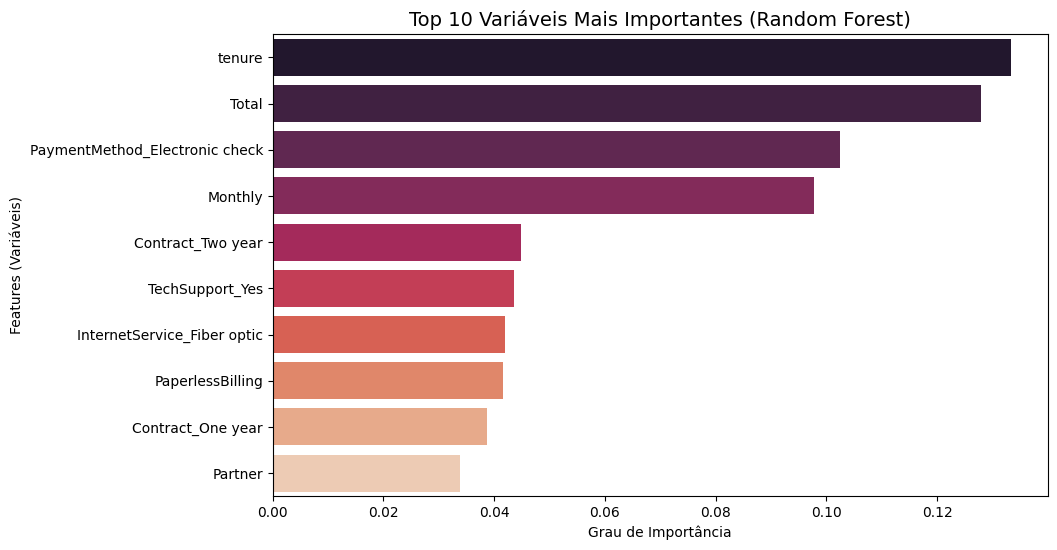

In [33]:
# Parte 3: Analisando as Features mais Importantes do Random Forest
importancias = rf_model.feature_importances_
df_importancias = pd.DataFrame({'Variável': X.columns, 'Importância': importancias})
df_importancias = df_importancias.sort_values(by='Importância', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importância', y='Variável', data=df_importancias, palette='rocket')
plt.title('Top 10 Variáveis Mais Importantes (Random Forest)', fontsize=14)
plt.xlabel('Grau de Importância')
plt.ylabel('Features (Variáveis)')
plt.show()

# Pare 4 Analise

📑 1. Relatório de Performance e Análise Técnica
🏁 Relatório de Desempenho dos Modelos
Nesta etapa, avaliamos a capacidade preditiva de algoritmos para prever a evasão de clientes (Churn). Para garantir que o modelo conseguisse capturar as nuances da classe minoritária (clientes que saem), aplicamos a técnica de balanceamento SMOTE nos dados de treinamento.

📊 Análise Crítica de Desempenho
Testamos modelos lineares e baseados em árvores. O modelo de Regressão Logística (com dados normalizados e balanceados) foi o grande vencedor para o nosso objetivo de negócio.

Foco Estratégico (Recall): Em problemas de Churn, o Recall (Sensibilidade) é a métrica mais importante, pois indica a capacidade de identificar os clientes que efetivamente vão cancelar. Nosso modelo obteve um Recall de 78%, conseguindo identificar corretamente 435 potenciais evasões no conjunto de teste.

Justificativa Técnica: A Regressão Logística exigiu a padronização prévia dos dados (StandardScaler), mas respondeu de forma excelente ao balanceamento (SMOTE), tornando-se altamente sensível ao risco. Modelos não lineares como o Random Forest mostraram boa Acurácia geral, mas pecaram na detecção específica da classe de evasão.

💡 2. Fatores de Influência e Estratégia de Negócio
📉 Fatores de Evasão e Estratégias de Retenção
A análise das variáveis mais relevantes (Feature Importance e Matriz de Correlação) confirmou padrões comportamentais claros que levam à saída dos clientes:

🚩 Principais Fatores de Risco
1. Tempo de Contrato (Tenure): O risco de perda é crítico nos primeiros meses. A mediana de permanência dos clientes evadidos gira em torno de 10 meses.

2. Tipo de Contrato: Planos de renovação mensal (Month-to-month) são o maior ofensor de churn, devido à ausência de barreiras de saída e fidelidade.

3. Internet Fibra Óptica: Existe uma correlação forte e positiva entre possuir Fibra Óptica e cancelar o serviço, apontando para uma possível insatisfação técnica ou baixa competitividade de preço.

🛡️ Plano de Ação Proposto
Para mitigar a evasão com base nos dados, propomos as seguintes ações estratégicas:

Onboarding VIP (Foco em Tenure): Concentrar esforços de suporte proativo, boas-vindas e acompanhamento de satisfação estritamente nos primeiros 6 meses de vida do cliente.

Conversão de Fidelidade (Foco em Contratos Mensais): Criar campanhas agressivas de desconto progressivo para clientes do plano mensal que aceitarem migrar para contratos de 1 ou 2 anos.

Auditoria Técnica de Fibra: Acionar as equipes de Produto e Engenharia para investigar a estabilidade, velocidade real entregue e o preço da Fibra Óptica frente aos concorrentes da região.

💰 Estimativa de Impacto Financeiro (ROI)
Ao utilizar o balanceamento de dados, nosso modelo superou as projeções anteriores (que identificavam em média 297 clientes) e ampliou significativamente a capacidade de retenção de receita da empresa.

Poder de Detecção: O modelo identificou 435 potenciais evasões.

Ticket Médio Estimado: R$ 65,00/mês.

Potencial de Recuperação: Se a equipe de retenção conseguir salvar apenas 20% desses clientes identificados (87 clientes) com as estratégias propostas:

Receita preservada mensalmente: R$ 5.655,00/mês.

Impacto de retenção anual projetado: + R$ 67.860,00.